In [1]:
import matplotlib.pyplot as plt
import seaborn as sns;
sns.set()
import numpy as np


In [2]:
#Generate some data
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=400,centers=4,
                  cluster_std=0.60,random_state=0)
X=X[:,::-1] #Flip the axes for better plotting

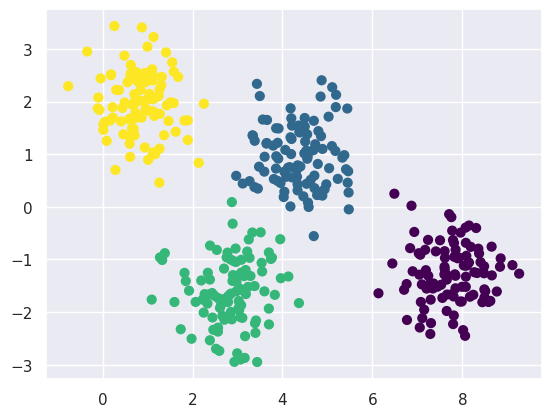

In [3]:
#Plot the data with K means labels
from sklearn.cluster import KMeans
kmeans=KMeans(4,random_state=0)
labels=kmeans.fit_predict(X)
plt.scatter(X[:,0],X[:,1],c=labels,s=40,cmap='viridis')

In [4]:
# When we have seperations like this we generally go for k means clustering


In [5]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

def plot_kmeans(kmeans,X,n_clusters=4,rseed=0,ax=None):
    labels=kmeans.fit_predict(X)
    #plot the input data
    ax=ax or plt.gca()
    ax.axis('equal')
    ax.scatter(X[:,0],X[:,1],c=labels,s=40,cmap='viridis',zorder=2)
    #Plot the represntation of the k-means model
    centers=kmeans.cluster_centers_
    radii=[cdist(X[labels==i],[center]).max() for i,center in enumerate(centers)]
    for c,r in zip(centers,radii):
      ax.add_patch(plt.Circle(c,r,fc='#CCCCCC',lw=3,alpha=0.5,zorder=1))

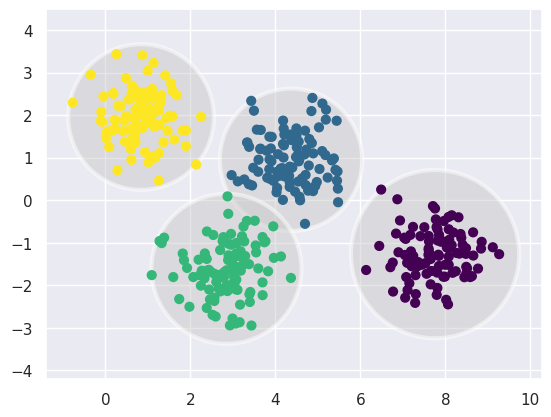

In [6]:
kmeans=KMeans(n_clusters=4,random_state=0)
plot_kmeans(kmeans,X)

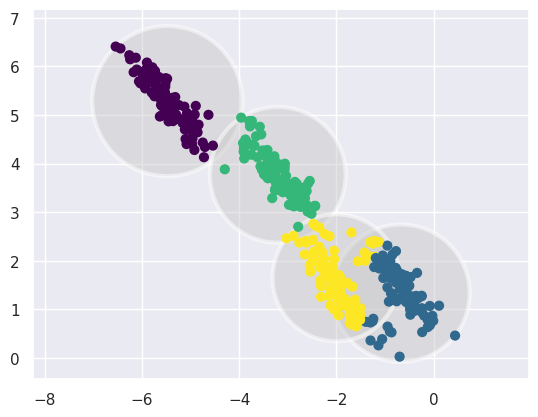

In [7]:
rng=np.random.RandomState(13)
X_stretched=np.dot(X,rng.randn(2,2))
kmeans=KMeans(n_clusters=4,random_state=0)
plot_kmeans(kmeans,X_stretched)

In [11]:
from sklearn.mixture import GaussianMixture
gmm=GaussianMixture(n_components=4).fit(X)
# labels=gmm.predict(X)

In [12]:
gmm.converged_

True

In [13]:
gmm.weights_

array([0.24757933, 0.24881629, 0.24967573, 0.25392865])

In [14]:
#So these are the weights like we prefer for go with 4 clusters
#wo saare probability ko add karo all this will sum to 1


In [15]:
gmm.means_

array([[ 2.84520475, -1.62515249],
       [ 7.76207921, -1.27617979],
       [ 0.8377989 ,  1.95781368],
       [ 4.36450124,  0.93400014]])

In [16]:
#Since there are 2-Dimensional so yaha pe mui1,mui2 hoga 4ro ke liye


In [18]:
#Since sigma is left here but here we are in 2D wo we will look for covariances_
gmm.covariances_

array([[[ 0.38494452,  0.02843666],
        [ 0.02843666,  0.37794793]],

       [[ 0.36544715,  0.01271038],
        [ 0.01271038,  0.28945443]],

       [[ 0.29790222, -0.02463781],
        [-0.02463781,  0.34185172]],

       [[ 0.40094166, -0.00447302],
        [-0.00447302,  0.36683582]]])

In [19]:
#What i get from it? Nothing

In [20]:
#It randomly initializes the value of Phi, then means , then covariances, then it iwll try to do Expectation Maximization
#Then wahi Expectation Maximization wala kaam krenge till me gmm conveges

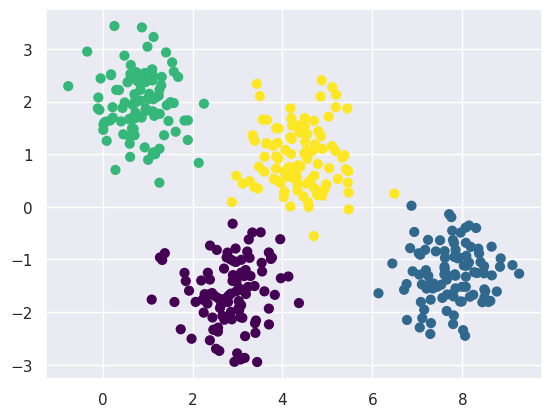

In [21]:
labels=gmm.predict(X)
plt.scatter(X[:,0],X[:,1],c=labels,s=40,cmap='viridis')

In [22]:
#Kmeans gives you hard lables while gmm gives you soft labels
#Probabilistic approach, in previous method we keep the predict method but here we willl keep predict probability too

In [23]:
probs=gmm.predict_proba(X)
print(probs.round(3))

[[0.    0.469 0.    0.531]
 [1.    0.    0.    0.   ]
 [1.    0.    0.    0.   ]
 ...
 [0.    0.    1.    0.   ]
 [0.463 0.    0.    0.536]
 [0.    0.    1.    0.   ]]


In [24]:
#Likelihood that it belong to Cluster1=0, Cluster0.469, Cluster3=0, Cluster=0.531
#Next Cluster mera 1st ko hi belong krta qki we can see it is 1

In [25]:
#There is no way that we say that it is good, like there is no validation
#it is buisness point of view
#if it is labelled data , you can try to use validation or metric
#but for clustering which is completely unsupervised there is no approach that we acn say whch clsuter is best
#Abhi aage hum case dekhenge like how clustering helps markets
#there our logic is they won't ask for how accurate is this clsuter
#they'll ask you how much meaning ful it is for clusters


In [26]:
#When we ran any model we go and look at parameter for it
#Jaise Gausssixture me bhut saara cheez hota
#like we can make computationally easy by
#covariance_type: like isme bahut saara covariance type hota hai so

#Every Cluster has its own good type

In [27]:
#The whole point of GMM isthat we don't want full spherical shape
#if you think that your data has speically elliptical shape then we will only figure out those elliptical curve as clusters

In [28]:
gmm.bic(X)

np.float64(2667.5548180155324)

In [29]:
gmm.aic(X)

np.float64(2575.751133432049)

In [30]:
#In GMM we use this BIC and AIC metric to decide the ideal value of k
#When you build a GMM Modle and pass it to get score which is log likelihood score
#You can try to run a loop and it will produce a graph which is very similiar to elbow graph

#It penalizes Parameters

#K more->More parameters
#so if the higher value of k->the number of parametr increase and due to penalization it will also increase BIC

In [31]:
from sklearn.mixture import BayesianGaussianMixture

In [32]:
bgm=BayesianGaussianMixture(n_components=10,random_state=0)
bgm.fit(X)
# labels=bgm.predict(X)
bgm.weights_.round(2)

array([0.25, 0.25, 0.  , 0.25, 0.24, 0.  , 0.  , 0.  , 0.  , 0.  ])